In [1]:
import torch
from torch.utils.data import DataLoader
import numpy as np
import pickle
import pandas as pd

import matplotlib.pyplot as plt

from matplotlib.colors import PowerNorm
from matplotlib.colors import LogNorm

from matrix_processing_helpers import sparsify_global_percentile
# from matrix_processing_helpers import sparsify_topk_rows
# from matrix_processing_helpers import reorder
# from matrix_processing_helpers import reorder_clustering

### Load data

In [2]:
# results_local = np.load("Results_TR/attention_rollout_local/rollout.npz")
results = np.load("Results/rollout_global/rollout.npz")

with open("data_processed/dataframes/input_cols_pruned.pkl", "rb") as f:
    INPUT_COLS_PRUNED = pickle.load(f)

feature_names = list(INPUT_COLS_PRUNED)

### Feature importance

In [3]:
importance = results['importance']
sorted_indices = np.argsort(importance)[::-1]
sorted_features_names = [feature_names[i] for i in sorted_indices]
sorted_values = importance[sorted_indices]

df = pd.DataFrame({'metabolite': sorted_features_names, 'attn_score': sorted_values})
df.to_csv("Results/rollout_global/features_importance.csv", index=False)
df.head()

,metabolite,attn_score
0,Albumin (g/dl),1.539620
1,Cystine (mM),1.463840
2,Erythrocyte sedimentation rate (mm/h),1.417091
3,LDL cholesterol (mg/dl),1.357646
4,"1,5-Anhydrosorbitol (mM)",1.283614


#### Plot: top-k feature importance

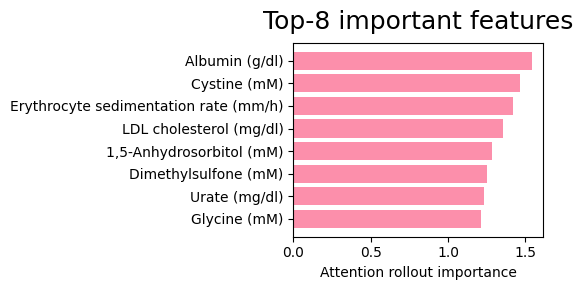

In [4]:
k = 8
color = [0.99, 0.56, 0.67]

top_idx = np.argsort(importance)[::-1][:k]
top_features = [feature_names[i] for i in top_idx]
top_values = importance[top_idx]

plt.figure(figsize=(5.7, 3))
plt.barh(range(k), top_values[::-1], color=color)
plt.yticks(range(k), top_features[::-1])
plt.xlabel("Attention rollout importance")

title = f"Top-{k} important features"
    
plt.title(title, fontsize=18, pad=10)
plt.tight_layout()
# plt.savefig(f"FiguresPaper/attention_rollout/importance_top{k}_{key}.pdf", bbox_inches="tight")
plt.show()

#### Plot: top-k attention rollout

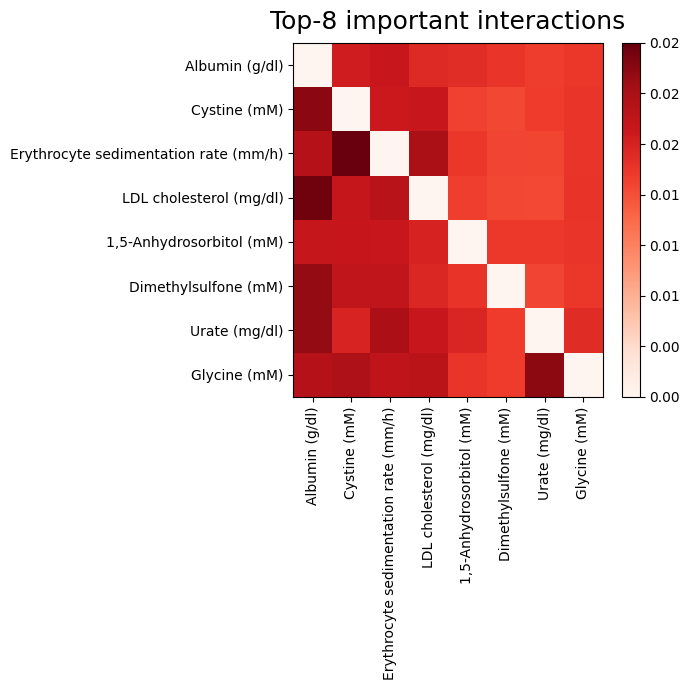

In [5]:
# top_idx = np.argsort(rankings[key])[::-1][:k]
matrix = results['rollout']
submatrix = matrix[np.ix_(top_idx, top_idx)]
subnames = [feature_names[i] for i in top_idx]

np.fill_diagonal(submatrix, 0)

plt.figure(figsize=(7, 7))
im = plt.imshow(submatrix, aspect='auto', cmap='Reds', 
                # norm=LogNorm(vmin=np.min(submatrix), vmax=np.max(submatrix))
               )

ticks = np.linspace(np.min(submatrix), np.max(submatrix), 8)
cbar = plt.colorbar(im, ticks=ticks)

cbar.set_ticklabels([f"{t:.2f}" for t in ticks])

plt.xticks(range(k), subnames, rotation=90)
plt.yticks(range(k), subnames)

title = f"Top-{k} important interactions"

plt.title(title, fontsize=18, pad=10)
plt.tight_layout()
# plt.savefig(f"FiguresPaper/attention_rollout/interactions_top{k}_{key}.pdf", bbox_inches="tight")
plt.show()

In [6]:
matrix.max()

0.14278165

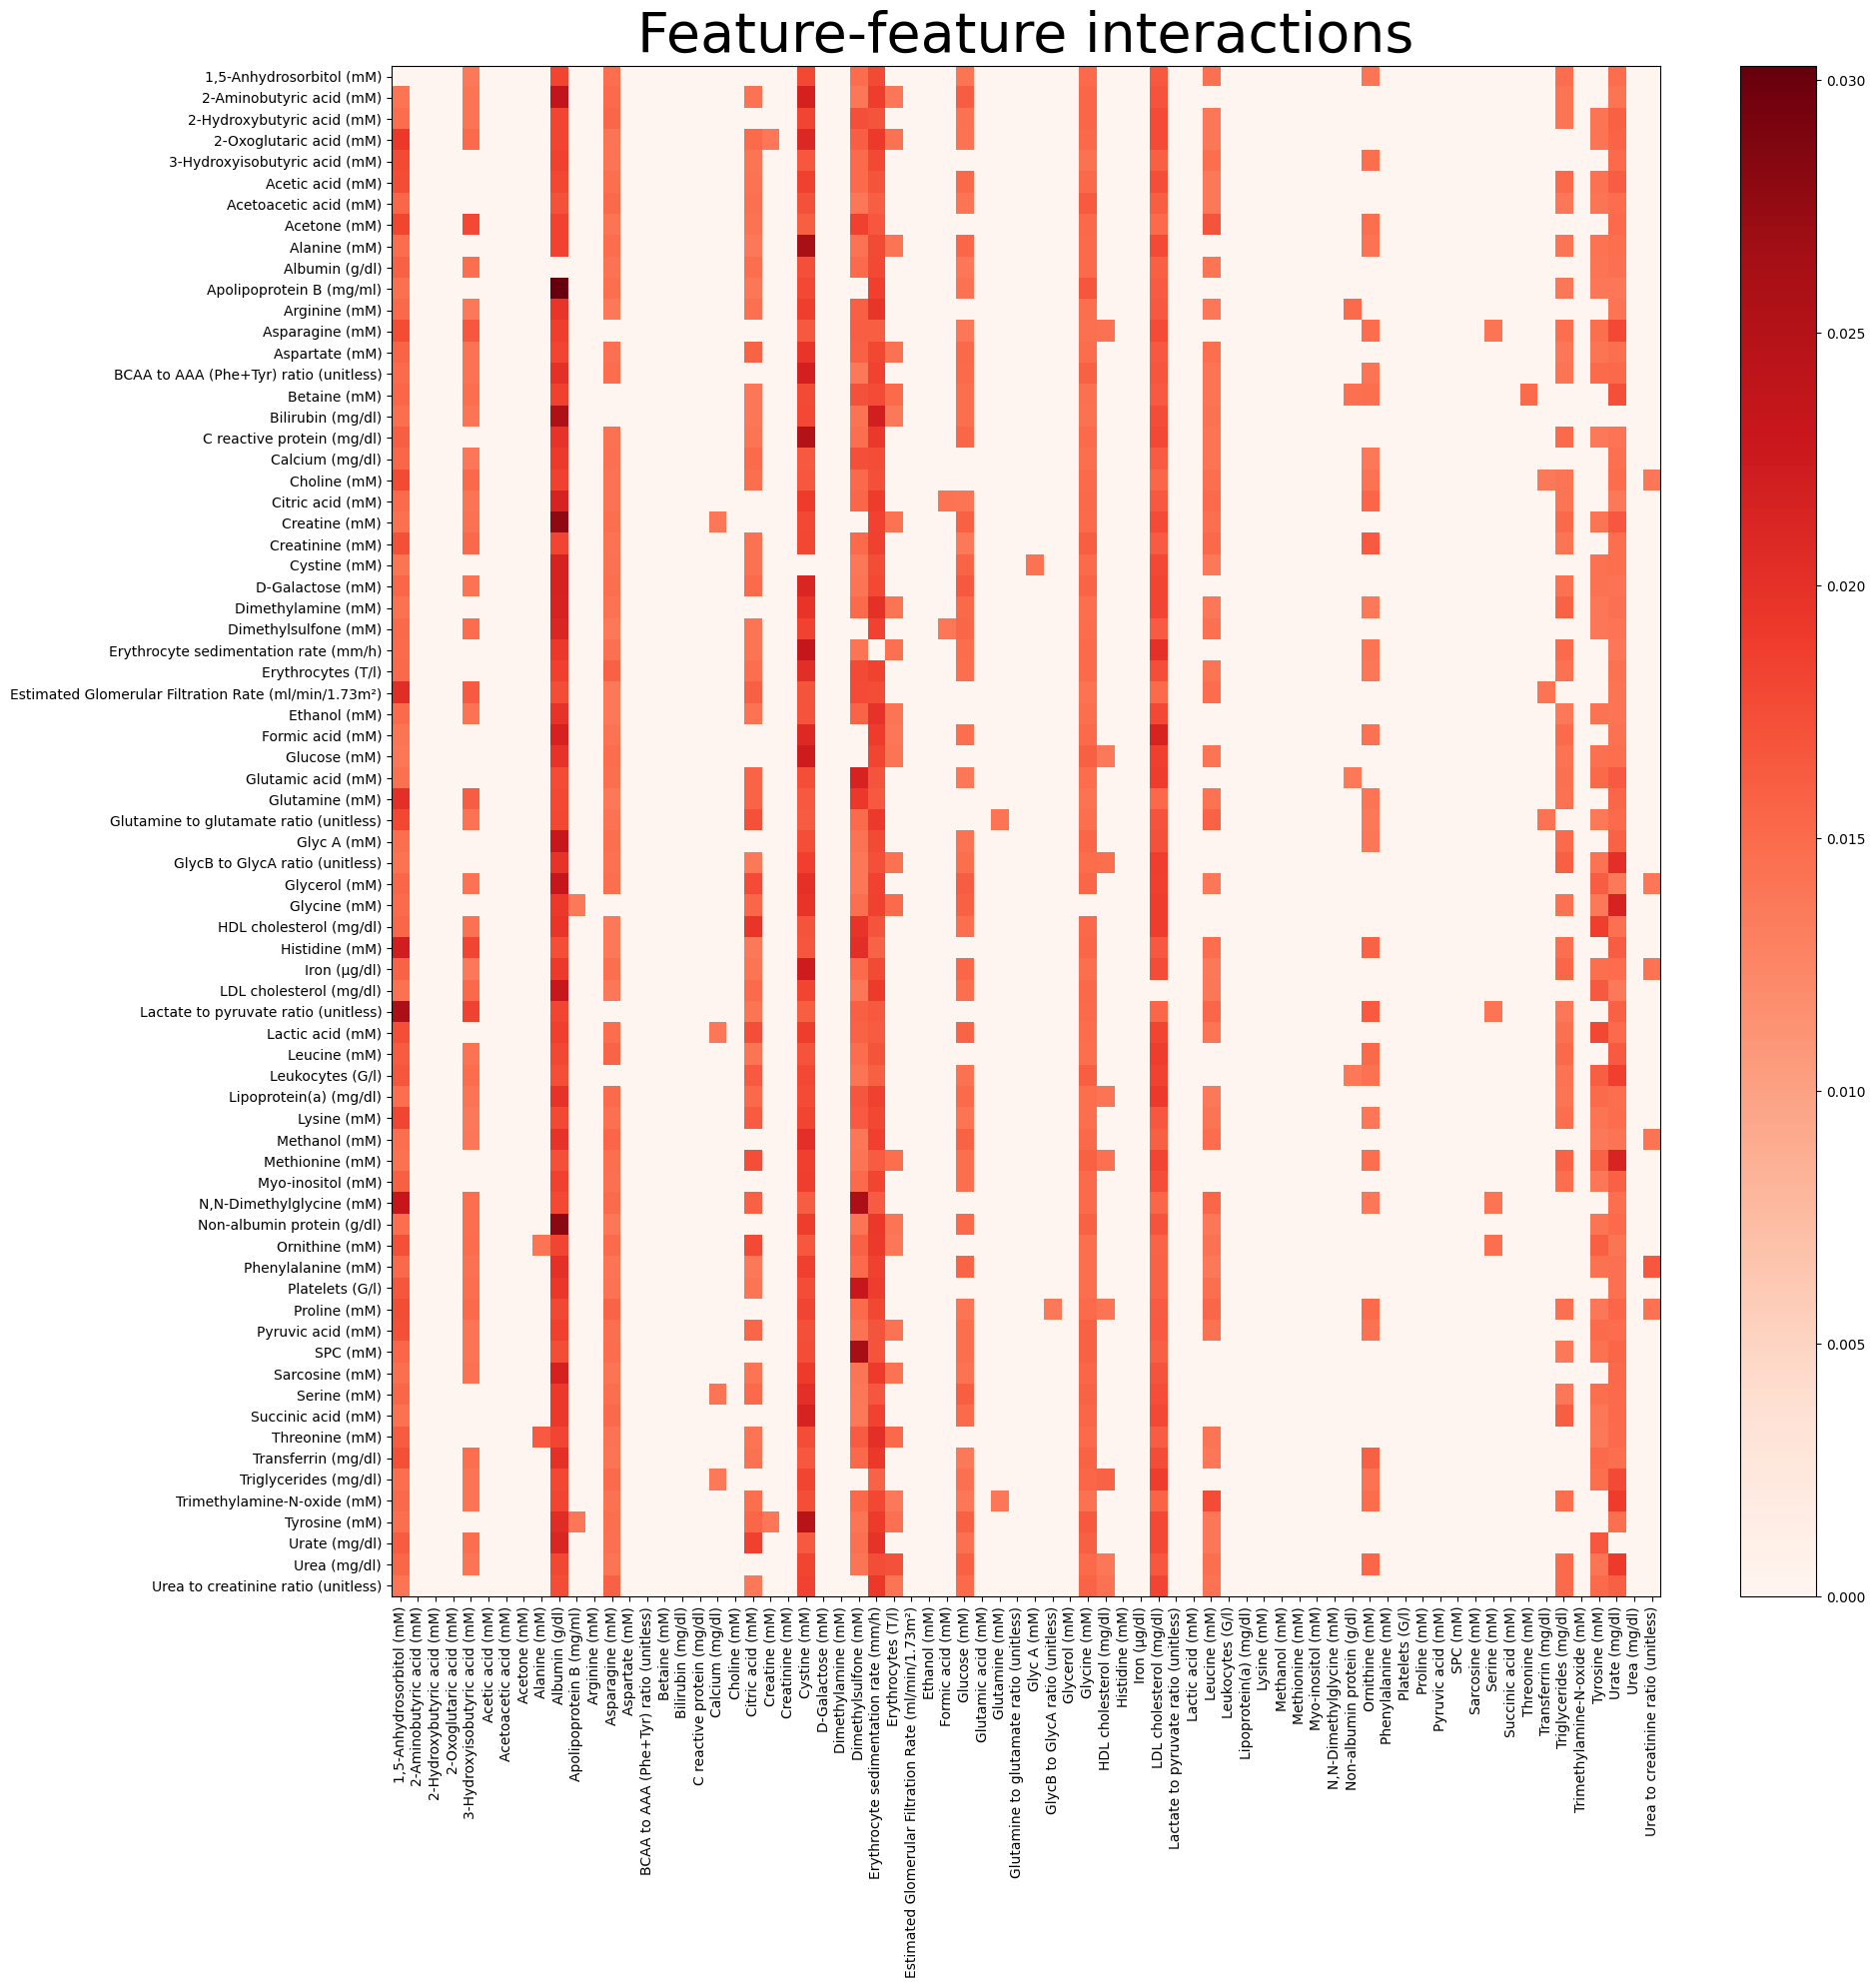

In [11]:
matrix_full = results['rollout']
np.fill_diagonal(matrix_full, 0)
matrix_full = sparsify_global_percentile(matrix_full, q=80, keep_diagonal=False)

plt.figure(figsize=(20, 20))
im = plt.imshow(matrix_full, aspect='auto', cmap="Reds", 
                # norm=LogNorm(vmin=matrix_full.min()+1e-3, vmax=matrix_full.max())
               )

title = "Feature-feature interactions"
    
plt.title(title, fontsize=40, pad=10)

cbar = plt.colorbar(im)
# cbar.set_ticklabels([f"{t:.2f}" for t in ticks[type]], fontsize=20)

plt.xticks(ticks=np.arange(len(feature_names)),
           labels=feature_names,
           rotation=90,
           fontsize=10)

plt.yticks(ticks=np.arange(len(feature_names)), 
           labels=feature_names, 
           fontsize=10)

plt.tight_layout()
# plt.savefig(f"FiguresPaper/attention_rollout/interactions_all_{key}.pdf", bbox_inches="tight")
plt.show()

### Entropy

In [8]:
def row_entropy(R, eps=1e-12, normalize=False):
    """
    Compute entropy H_i for each node i from adjacency matrix R.

    Parameters:
        R : np.ndarray (d x d), nonnegative weights
        eps : small constant to avoid log(0)

    Returns:
        H : np.ndarray (d,), entropy per row
    """
    R = np.asarray(R, dtype=float)

    # Normalize rows to sum to 1
    if normalize: 
        row_sums = R.sum(axis=1, keepdims=True)
        P = R / (row_sums + eps)
    else: P=R

    # Compute entropy
    H = -np.sum(P * np.log(P + eps), axis=1)

    return H

In [9]:
def column_entropy(R, eps=1e-12, normalize=False):
    """
    Compute entropy H_i for each node i from adjacency matrix R.

    Parameters:
        R : np.ndarray (d x d), nonnegative weights
        eps : small constant to avoid log(0)

    Returns:
        H : np.ndarray (d,), entropy per row
    """
    R = np.asarray(R, dtype=float)

    # Normalize rows to sum to 1
    if normalize: 
        row_sums = R.sum(axis=1, keepdims=True)
        P = R / (row_sums + eps)
    else: P=R

    # Compute entropy
    H = -np.sum(P * np.log(P + eps), axis=0)

    return H

In [10]:
I = results['rollout']
entropy_rows = row_entropy(I, normalize=True)
entropy_columns = column_entropy(I, normalize=True)
print('ROWS: ', entropy_rows)
print('COLUMNS: ', entropy_columns)

ROWS:  [4.05799102 4.06217942 4.06814969 4.06556658 4.06223677 4.06869986
 4.07180102 4.06664238 4.06080574 4.05471696 4.05808322 4.07049027
 4.0633528  4.0711304  4.06590422 4.06779175 4.06275422 4.06603701
 4.06647905 4.06763332 4.05714238 4.05737577 4.06888999 4.05377461
 4.06472385 4.06614102 4.06057119 4.04803153 4.06179098 4.06622369
 4.06824581 4.05848978 4.05367975 4.06414044 4.06543041 4.07069377
 4.06530146 4.06177873 4.06373684 4.0564929  4.05880279 4.06132575
 4.06480992 4.05379271 4.06251463 4.06821839 4.06243145 4.06518725
 4.06782022 4.07009018 4.06618052 4.06273268 4.0670412  4.06196828
 4.05827893 4.06261233 4.06896296 4.06439329 4.06987224 4.07215844
 4.05859197 4.06837009 4.06548442 4.06711679 4.06867495 4.06297506
 4.05969631 4.07091189 4.05121081 4.05693015 4.06369131 4.06103952]
COLUMNS:  [4.9858384  4.03077349 3.77184804 3.70947954 4.57835456 3.50113922
 3.80017462 3.61930199 4.11664142 5.75430274 4.09196324 3.50723038
 4.62225968 3.42805291 3.66092763 3.86204723